In [248]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import scipy.stats as st
from collections import defaultdict
from statannotations.Annotator import Annotator
from scikit_posthocs import posthoc_dunn
pd.set_option('future.no_silent_downcasting', True)

sns.set(font_scale=1.2, style='ticks', font='Helvetica Neue')

In [249]:
figure_folder = Path('../../Figures/interactions')
figure_folder.mkdir(exist_ok=True)

In [250]:
folder = Path('../../data/5_interactions/')

spent_mannose_fn = folder / 'cfus_spent_mannose.csv'
fresh_mannose_fn = folder / 'cfus_fresh_mannose.csv'
spent_malate_fn = folder / 'cfus_spent_malate.csv'
fresh_malate_fn = folder / 'cfus_fresh_malate.csv'

files = [spent_mannose_fn, fresh_mannose_fn, spent_malate_fn, fresh_malate_fn]
dfs = []
for fn in files:
    df = pd.read_csv(fn, index_col=0)
    if 'spent' in str(fn):
        df['spent'] = True
    
    else:
        df['spent'] = False
    df['fn'] = fn.stem
    dfs.append(df)
df = pd.concat(dfs)

In [251]:
df.Medium.unique()

array([nan, 'Ml_mannose', 'Ct_isoleucine', 'Oa_mannose', 'No_CS',
       'At_mannose', 'M9_mannose', 'M9_mannose+thiamine',
       'M9_mannose+thiamine+biotin+cysteine+proline', 'M9_isoleucine',
       'M9_isoleucine+thiamine+biotin+cysteine+proline',
       'M9_isoleucine+thiamine', 'At-malate', 'Ct-malate', 'Ml-malate',
       'Oa-malate', 'No-CS', 'M9-malate', 'M9-malate+thiamine',
       'M9-malate+thiamine+biotin+cysteine+proline'], dtype=object)

In [252]:
df_inoc_SM = df.loc[(df['Well'] == 'Inoculum')&(df.spent)].copy()
df_inoc_FM = df.loc[(df['Well'] == 'Inoculum')&(~df.spent)].copy()
df_inoc =  df.loc[(df['Well'] == 'Inoculum')].copy()

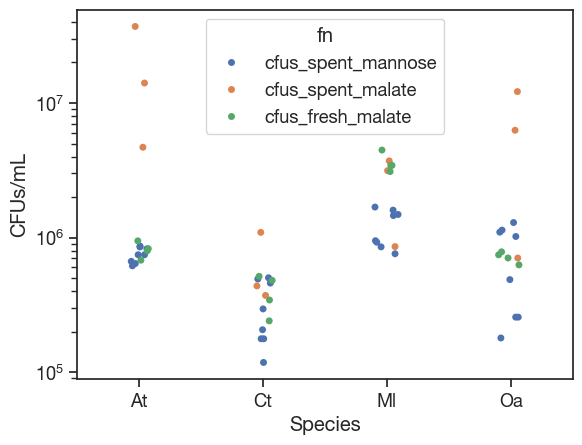

In [253]:
sns.stripplot(df_inoc, x = 'Species', y = 'CFUs/mL', hue = 'fn')
plt.yscale('log')

In [254]:
df

,Well,Plate,CFUs/mL,Species,Inoculated species,Medium,Initial OD,spent,fn
0,Inoculum,0,8.641975e+05,At,NaN,NaN,0.001,True,cfus_spent_mannose
1,Inoculum,0,6.666667e+05,At,NaN,NaN,0.001,True,cfus_spent_mannose
2,Inoculum,0,6.419753e+05,At,NaN,NaN,0.001,True,cfus_spent_mannose
3,Inoculum,0,6.172840e+05,At,NaN,NaN,0.001,True,cfus_spent_mannose
31,B10,2,2.000000e+08,At,At+Ct,Ml_mannose,0.001,True,cfus_spent_mannose
...,...,...,...,...,...,...,...,...,...
391,H8,6,7.800000e+09,Oa,Oa,M9-malate+thiamine,NaN,False,cfus_fresh_malate
392,H9,6,NaN,Oa,At,M9-malate+thiamine+biotin+cysteine+proline,NaN,False,cfus_fresh_malate
393,H10,6,NaN,Oa,Ct,M9-malate+thiamine+biotin+cysteine+proline,NaN,False,cfus_fresh_malate
394,H11,6,NaN,Oa,Ml,M9-malate+thiamine+biotin+cysteine+proline,NaN,False,cfus_fresh_malate


In [255]:
inoculum_cfus = df_inoc.groupby('Species')['CFUs/mL'].median()

In [256]:
inoculum_cfus.mean()

np.float64(885922.9669936436)

In [257]:
# Remove nan rows
df.dropna(subset=['CFUs/mL', 'Medium'], inplace=True)
# df.loc[(df.Medium.isna())].iloc[40:80]

In [258]:
# Remove inoculum wells
df = df.loc[df['Well'] != 'Inoculum']

# Remove nan rows
df = df.dropna(subset=['CFUs/mL'])

df.replace(['No_CS', 'No-CS'], 'No CS', inplace=True)
df['Medium'] = df['Medium'].str.replace('-', '_')

df['Base carbon source'] = [x.split('+')[0].capitalize() if isinstance(x, str) else 'No CS'  for x in  df.Medium.str.replace('_','-').str.split('-').str[1]]

df.reset_index(drop=True, inplace=True)
df.head()

,Well,Plate,CFUs/mL,Species,Inoculated species,Medium,Initial OD,spent,fn,Base carbon source
0,B10,2,200000000.0,At,At+Ct,Ml_mannose,0.001,True,cfus_spent_mannose,Mannose
1,C11,2,300000000.0,At,At+Oa,Ml_mannose,0.001,True,cfus_spent_mannose,Mannose
2,D1,2,520000000.0,At,At,Ct_isoleucine,0.001,True,cfus_spent_mannose,Isoleucine
3,D4,2,260000000.0,At,At+Ml,Ct_isoleucine,0.001,True,cfus_spent_mannose,Isoleucine
4,D5,2,300000000.0,At,At+Oa,Ct_isoleucine,0.001,True,cfus_spent_mannose,Isoleucine


In [259]:
df.loc[df.Medium!='No CS'].sort_values(by = 'CFUs/mL').head(20)

,Well,Plate,CFUs/mL,Species,Inoculated species,Medium,Initial OD,spent,fn,Base carbon source
309,F3,5,40000.0,Ml,Ml,M9_mannose,0.001,False,cfus_fresh_mannose,Mannose
316,H7,5,120000.0,Ml,Ml,M9_mannose+thiamine,0.001,False,cfus_fresh_mannose,Mannose
310,F7,5,180000.0,Ml,Ml,M9_mannose+thiamine,0.001,False,cfus_fresh_mannose,Mannose
306,E3,5,200000.0,Ml,Ml,M9_mannose,0.001,False,cfus_fresh_mannose,Mannose
312,G3,5,240000.0,Ml,Ml,M9_mannose,0.001,False,cfus_fresh_mannose,Mannose
307,E7,5,240000.0,Ml,Ml,M9_mannose+thiamine,0.001,False,cfus_fresh_mannose,Mannose
313,G7,5,260000.0,Ml,Ml,M9_mannose+thiamine,0.001,False,cfus_fresh_mannose,Mannose
455,C8,4,300000.0,Ml,Ml,Ml_malate,NaN,True,cfus_spent_malate,Malate
456,C9,4,340000.0,Ml,Ml,Ml_malate,NaN,True,cfus_spent_malate,Malate
454,C7,4,520000.0,Ml,Ml,Ml_malate,NaN,True,cfus_spent_malate,Malate


<Axes: xlabel='CFUs/mL', ylabel='Density'>

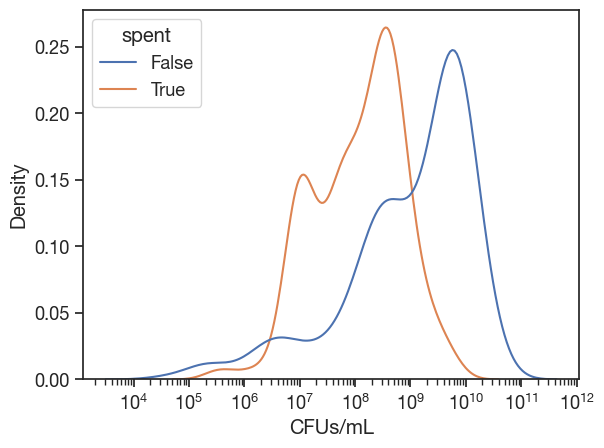

In [260]:
sns.kdeplot(df.loc[df.Medium!='No CS'], x = 'CFUs/mL', hue = 'spent', log_scale=True)
# plt.xscale('log')

In [261]:
df['Base carbon source'].unique()

array(['Mannose', 'Isoleucine', 'No CS', 'Malate'], dtype=object)

In [262]:
print(df.Medium.unique())

df['Base carbon source'].unique()
species_list = ['At', 'Ct', 'Ml', 'Oa']
for i, row in df.iterrows():
    if row['Medium'].split('_')[0] in species_list:
        short_name = row['Medium'].split('_')[0]
        bg = row['Medium'].split('_')[0]
    elif row['Medium']=='No CS':
        short_name = 'No CS'
        bg = 'No CS'
    else:
        short_name = 'Fresh'
        bg = 'Fresh'
        if row['Medium'].split('+')[-1]=='thiamine':
            short_name += ' + T'
        elif row['Medium'].split('+')[-1]=='proline':
            short_name += ' + Vit. & AA'
    
    if '+' in row['Inoculated species']:
        partner = row['Inoculated species'].replace(row['Species'], '').replace('+', '')
        short_name += f' ({partner})'
    else:
        partner = 'No partner'
    
    if bg == 'Fresh':
        if '+' in row['Inoculated species']:
            bg += ' (coculture)'
        else:
            bg += ' (monoculture)'

    df.at[i, 'Short name'] = short_name
    df.at[i, 'Background'] = bg
    df.at[i, 'Partner'] = partner
    


['Ml_mannose' 'Ct_isoleucine' 'Oa_mannose' 'No CS' 'At_mannose'
 'M9_mannose' 'M9_mannose+thiamine'
 'M9_mannose+thiamine+biotin+cysteine+proline' 'M9_isoleucine'
 'M9_isoleucine+thiamine+biotin+cysteine+proline' 'M9_isoleucine+thiamine'
 'At_malate' 'Ct_malate' 'Ml_malate' 'Oa_malate' 'M9_malate'
 'M9_malate+thiamine' 'M9_malate+thiamine+biotin+cysteine+proline']


In [263]:
df.loc[(df.Medium == 'M9_isoleucine')&(df.Plate==3), 'Short name'] = 'Fresh'
df.loc[(df.Medium == 'No CS')&(df.Plate==3), 'Short name'] = 'No CS 2'
df.loc[(df.Medium == 'Ct_isoleucine')&(df.Plate==3), 'Short name'] =df.loc[(df.Medium == 'Ct_isoleucine')&(df.Plate==3), 'Short name'] + ' 2'


# Plot

In [264]:
df['Base carbon source'].unique()

array(['Mannose', 'Isoleucine', 'No CS', 'Malate'], dtype=object)

In [265]:
tab10 = sns.color_palette('tab10')
partner_palette = {
    'At': tab10[2],
    'Ct': tab10[1],
    'Oa': tab10[3],
    'Ml': tab10[0],
    'No partner': 'k',
}

# At

['Ml (Ct)' 'Ml (Oa)' 'Oa (Ml)' 'No CS' 'At' 'Ml' 'Oa' 'Oa (Ct)'
 'Fresh (Ct)' 'Fresh (Ml)' 'Fresh (Oa)' 'Fresh + T (Oa)'
 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T' 'Fresh + Vit. & AA'] 16
16


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/552914330.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


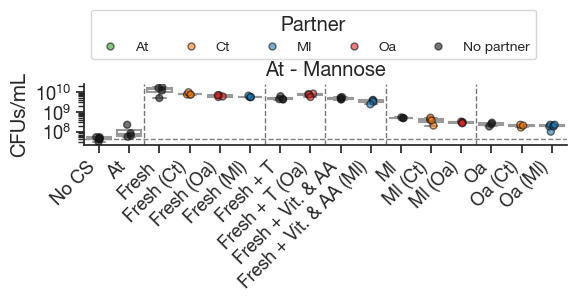

In [266]:
s = 'At'
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'At',
         'Fresh', 
          'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
        #  'Ct', 'Ct (Ml)', 'Ct (Oa)',

         'Ml', 'Ml (Ct)', 'Ml (Oa)',
         'Oa', 'Oa (Ct)', 'Oa (Ml)',

         ]

fig, ax = plt.subplots(figsize=(6, 4))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 7.5, 9.5, 12.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
# ax.text(9.7, df.loc[sidx, 'CFUs/mL'].max(), 'Isoleucine', fontsize=12, ha='left', va='center', rotation=0)
sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.3)  , loc='lower left', fontsize=10)

ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')

4


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/4273028588.py:40: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


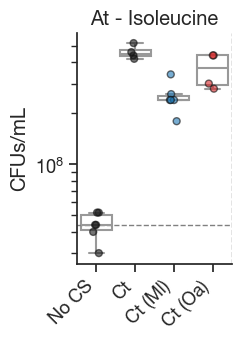

In [267]:
#Isoleucine

s = 'At'
cs = 'Isoleucine'
bcs = [cs, 'No CS']
plates = [2]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs)&(df['Plate'].isin(plates)))
order = ['No CS', 
        #  'At',
        #   'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
        #  'Fresh + T', 'Fresh + T (Oa)',
        #  'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'Ct', 'Ct (Ml)', 'Ct (Oa)',
        #  'No CS 2',
        #           'Fresh',
        #           'Ct 2' 
         
         ]
fig, ax = plt.subplots(figsize=(2, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees
sns.despine(fig, ax=ax)
ax.axvline(x=3.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
no_cs_mean = df.loc[sidx&(df['Short name']=='No CS'), 'CFUs/mL'].median()
no_cs_mean2 = df.loc[sidx&(df['Short name']=='No CS 2'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, xmin=0,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, xmin=0.6,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, color='grey', linestyle='--', linewidth=1)
ax.set_title(f'{s} - {cs}')
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')

['At' 'Ct' 'Ml' 'Oa' 'No CS' 'Ct (Ml)' 'Ml (Ct)' 'Oa (Ct)' 'Ct (Oa)'
 'Ml (Oa)' 'Oa (Ml)' 'Fresh (Ct)' 'Fresh (Ml)' 'Fresh (Oa)'
 'Fresh + T (Oa)' 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T'
 'Fresh + Vit. & AA'] 19
19


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/4150745095.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


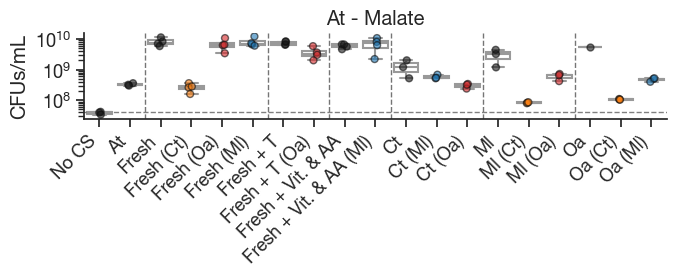

In [268]:
s = 'At'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'At',
         'Fresh', 
         'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'Ct', 'Ct (Ml)', 'Ct (Oa)',

         'Ml', 'Ml (Ct)', 'Ml (Oa)',
         'Oa', 'Oa (Ct)', 'Oa (Ml)',

         ]

fig, ax = plt.subplots(figsize=(7, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 7.5, 9.5, 12.5, 15.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
# ax.text(9.7, df.loc[sidx, 'CFUs/mL'].max(), 'Isoleucine', fontsize=12, ha='left', va='center', rotation=0)
# sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.3)  , loc='lower left', fontsize=10)

ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


# Ct

In [269]:
# df.loc[(df['Species']=='Ct')&(df['Base carbon source']=='Mannose')&(df['Short name']=='Fresh + T'), 'CFUs/mL'] *= 10

['At' 'At (Ml)' 'At (Oa)' 'Ml' 'Ml (At)' 'Oa' 'Oa (Ml)' 'No CS' 'Ml (Oa)'
 'Oa (At)' 'Fresh (At)' 'Fresh (Ml)' 'Fresh (Oa)' 'Fresh + T (Oa)'
 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T' 'Fresh + Vit. & AA'] 18
18


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/2336812910.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


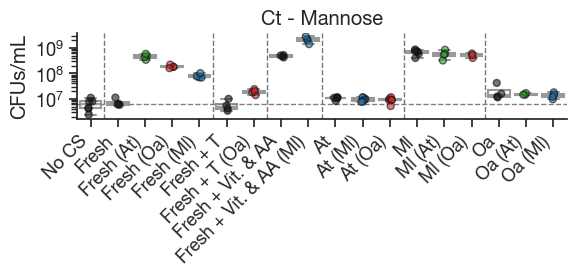

In [270]:
s = 'Ct'
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Fresh', 
          'Fresh (At)', 'Fresh (Oa)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'At', 'At (Ml)', 'At (Oa)',

         'Ml', 'Ml (At)', 'Ml (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ml)',

         ]

fig, ax = plt.subplots(figsize=(6, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ml', 'Oa', 'No partner'],
                # hue = 'Base carbon source',
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [0.5, 4.5, 6.5, 8.5, 11.5, 14.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


['No CS' 'Ct' 'Ct 2' 'Fresh' 'No CS 2'] 5


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/276072428.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


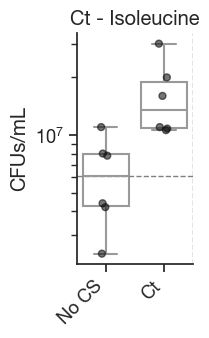

In [271]:
#Isoleucine

s = 'Ct'
cs = 'Isoleucine'
bcs = [cs, 'No CS']
plates = [2,3]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs)&(df['Plate'].isin(plates)))
order = ['No CS', 
        #  'At',
        #   'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
        #  'Fresh + T', 'Fresh + T (Oa)',
        #  'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'Ct', 
        #  'No CS 2',
        #           'Fresh',
        #           'Ct 2' 
         
         ]

fig, ax = plt.subplots(figsize=(1.5, 3))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees
sns.despine(fig, ax=ax)
ax.axvline(x=1.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
no_cs_mean = df.loc[sidx&(df['Short name']=='No CS'), 'CFUs/mL'].median()
no_cs_mean2 = df.loc[sidx&(df['Short name']=='No CS 2'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, xmin=0,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, xmin=0.5,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, color='grey', linestyle='--', linewidth=1)
ax.set_title(f'{s} - {cs}')
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')

['At' 'Ct' 'Ml' 'Oa' 'At (Ml)' 'Ml (At)' 'Oa (At)' 'At (Oa)' 'Ml (Oa)'
 'Oa (Ml)' 'Fresh (At)' 'Fresh (Ml)' 'Fresh (Oa)' 'Fresh + T (Oa)'
 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T' 'Fresh + Vit. & AA'] 18
19


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/56239609.py:42: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


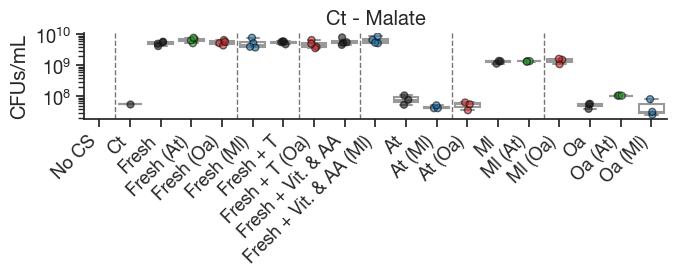

In [272]:
s = 'Ct'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Ct',
         'Fresh', 
          'Fresh (At)', 'Fresh (Oa)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'At', 'At (Ml)', 'At (Oa)',

         'Ml', 'Ml (At)', 'Ml (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ml)',

         ]

fig, ax = plt.subplots(figsize=(7, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [0.5, 4.5, 6.5, 8.5, 11.5, 14.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
# ax.text(9.7, df.loc[sidx, 'CFUs/mL'].max(), 'Isoleucine', fontsize=12, ha='left', va='center', rotation=0)
# sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.3)  , loc='lower left', fontsize=10)

ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


# Ml

['At' 'At (Ct)' 'At (Oa)' 'Oa (At)' 'Oa (Ct)' 'No CS' 'Ml' 'Oa'
 'Fresh (At)' 'Fresh (Ct)' 'Fresh (Oa)' 'Fresh + T (Oa)'
 'Fresh + Vit. & AA (At)' 'Fresh + Vit. & AA (Ct)'
 'Fresh + Vit. & AA (Oa)' 'Fresh' 'Fresh + T' 'Fresh + Vit. & AA'] 18
18


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/1340682351.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


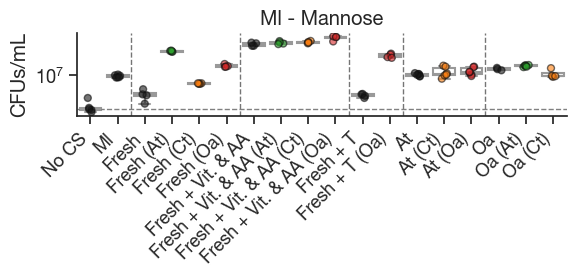

In [273]:
s = 'Ml'
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Ml',
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
            'Fresh + Vit. & AA (Oa)',
         
         'Fresh + T', 'Fresh + T (Oa)',
         'At', 'At (Ct)', 'At (Oa)',

        #  'Ct', 'Ct (At)', 'Ct (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ct)',

         ]

fig, ax = plt.subplots(figsize=(6, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ml', 'Oa', 'No partner'],
                # hue = 'Base carbon source',
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 9.5, 11.5, 14.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


['Ct' 'Ct (At)' 'Ct (Oa)' 'No CS'] 4


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/495419047.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


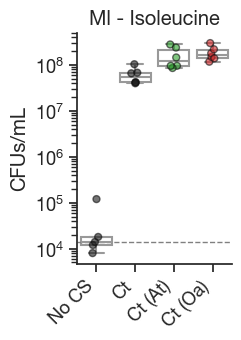

In [274]:
#Isoleucine

s = 'Ml'
cs = 'Isoleucine'
bcs = [cs, 'No CS']
plates = [2]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs)&(df['Plate'].isin(plates)))
order = ['No CS', 
         #   'Fresh + Vit. & AA',
        #  'At',
        #   'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
        #  'Fresh + T', 'Fresh + T (Oa)',
        #  'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'Ct', 
         'Ct (At)',
         'Ct (Oa)',


         # 'No CS 2',
                  # 'Fresh',
                  # 'Ct 2' 
         
         ]

fig, ax = plt.subplots(figsize=(2, 3))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees
sns.despine(fig, ax=ax)
# ax.axvline(x=4.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
no_cs_mean = df.loc[sidx&(df['Short name']=='No CS'), 'CFUs/mL'].median()
no_cs_mean2 = df.loc[sidx&(df['Short name']=='No CS 2'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, xmin=0,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, xmin=0.7,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, color='grey', linestyle='--', linewidth=1)
ax.set_title(f'{s} - {cs}')
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


['At' 'Ct' 'Ml' 'Oa' 'No CS' 'At (Ct)' 'Ct (At)' 'Oa (At)' 'At (Oa)'
 'Ct (Oa)' 'Oa (Ct)' 'Fresh (At)' 'Fresh (Ct)' 'Fresh (Oa)'
 'Fresh + T (Oa)' 'Fresh + Vit. & AA (At)' 'Fresh + Vit. & AA (Ct)'
 'Fresh + Vit. & AA (Oa)' 'Fresh + T' 'Fresh + Vit. & AA' 'Fresh'] 21
21


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/4137059761.py:44: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


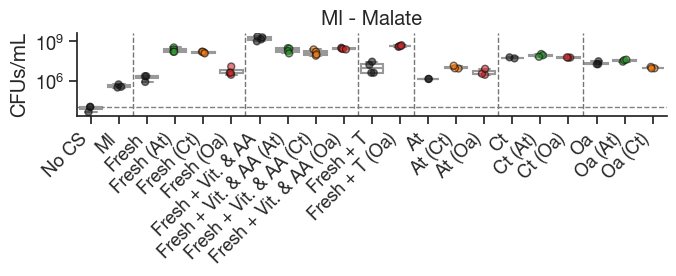

In [275]:
s = 'Ml'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Ml',
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Oa)',
         'Fresh + Vit. & AA', 'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
            'Fresh + Vit. & AA (Oa)',
         
         'Fresh + T', 'Fresh + T (Oa)',
         'At', 'At (Ct)', 'At (Oa)',

         'Ct', 'Ct (At)', 'Ct (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ct)',

         ]

fig, ax = plt.subplots(figsize=(7, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ml', 'Oa', 'No partner'],
                # hue = 'Base carbon source',
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 9.5, 11.5, 14.5, 17.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


# Oa

['At' 'At (Ct)' 'At (Ml)' 'Ml' 'Ml (At)' 'No CS' 'Oa' 'Ml (Ct)'
 'Fresh (At)' 'Fresh (Ct)' 'Fresh (Ml)' 'Fresh + T (At)' 'Fresh + T (Ct)'
 'Fresh + T (Ml)' 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T'
 'Fresh + Vit. & AA'] 18
18


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/1360809093.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


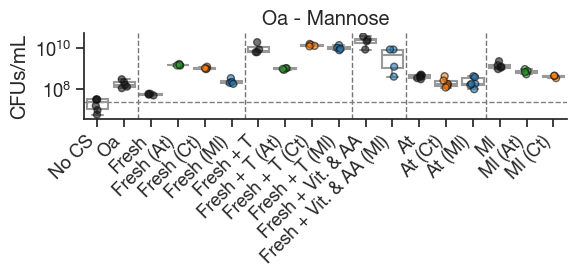

In [276]:
s = 'Oa'
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Oa',
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)',
        'Fresh + T (Ml)',
        'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'At', 'At (Ct)', 'At (Ml)',

        #  'Ct', 'Ct (At)', 'Ct (Oa)',
         'Ml', 'Ml (At)', 'Ml (Ct)',
        



         ]

fig, ax = plt.subplots(figsize=(6, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ml', 'Oa', 'No partner'],
                # hue = 'Base carbon source',
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 9.5, 11.5, 14.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


['Ct' 'Ct (At)' 'Ct (Ml)' 'No CS'] 4


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/578865198.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


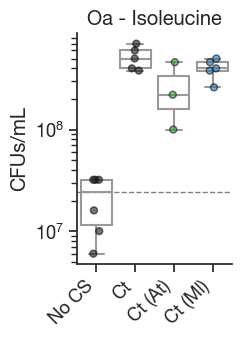

In [277]:
#Isoleucine

s = 'Oa'
cs = 'Isoleucine'
bcs = [cs, 'No CS']
plates = [2]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs)&(df['Plate'].isin(plates)))
order = ['No CS', 
         #   'Fresh + T',
        #  'At',
        #   'Fresh (Ct)', 'Fresh (Oa)', 'Fresh (Ml)',
        #  'Fresh + T', 'Fresh + T (Oa)',
        #  'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'Ct', 
         'Ct (At)',
         'Ct (Ml)',


         # 'No CS 2',
                  # 'Fresh',
                  # 'Ct 2' 
         
         ]

fig, ax = plt.subplots(figsize=(2, 3))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees
sns.despine(fig, ax=ax)
# ax.axvline(x=4.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
no_cs_mean = df.loc[sidx&(df['Short name']=='No CS'), 'CFUs/mL'].median()
no_cs_mean2 = df.loc[sidx&(df['Short name']=='No CS 2'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, xmin=0,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, xmin=0.7,xmax=1, color='grey', linestyle='--', linewidth=1)
# ax.axhline(y=no_cs_mean2, color='grey', linestyle='--', linewidth=1)
ax.set_title(f'{s} - {cs}')
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')


['At' 'Ct' 'Ml' 'Oa' 'No CS' 'At (Ct)' 'Ct (At)' 'Ml (At)' 'At (Ml)'
 'Ct (Ml)' 'Ml (Ct)' 'Fresh (At)' 'Fresh (Ct)' 'Fresh (Ml)'
 'Fresh + T (At)' 'Fresh + T (Ct)' 'Fresh + T (Ml)'
 'Fresh + Vit. & AA (Ml)' 'Fresh' 'Fresh + T' 'Fresh + Vit. & AA'] 21
21


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/3678094694.py:43: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees


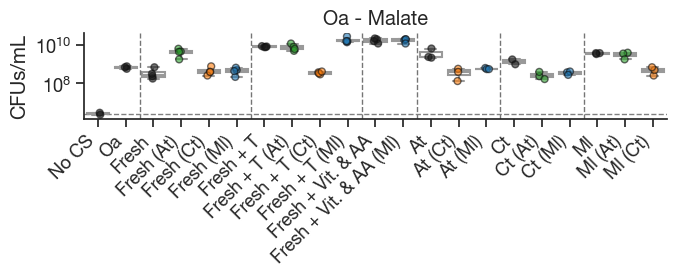

In [278]:
s = 'Oa'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
sn = df.loc[sidx, 'Short name'].unique()
print(sn, len(sn))
order = ['No CS', 
         'Oa',
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)',
         'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)',
        'Fresh + T (Ml)',
        'Fresh + Vit. & AA', 'Fresh + Vit. & AA (Ml)',
         'At', 'At (Ct)', 'At (Ml)',

         'Ct', 'Ct (At)', 'Ct (Ml)',
         'Ml', 'Ml (At)', 'Ml (Ct)',

         ]

fig, ax = plt.subplots(figsize=(7, 3))
print(len(order))
sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                # hue='Partner',palette=partner_palette, 
                ax=ax,
                color = 'w',
                fliersize=0,
                linewidth=1.5,)  
ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                order = order,
                legend=False,
                # aspect=2, height=3, 
                hue='Partner',palette=partner_palette, 
                hue_order=['At', 'Ml', 'Oa', 'No partner'],
                # hue = 'Base carbon source',
                ax=ax,
                alpha=0.6,
                linewidth=1)
plt.yscale('log')
ax.set(xlabel='')
# Rotate x-axis labels
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')  # Rotate labels 45 degrees

for x in [1.5, 5.5, 9.5, 11.5, 14.5, 17.5]:
    ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)

no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
sns.despine(fig, ax=ax)
ax.set_title(f'{s} - {cs}')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{s}_{cs}.pdf')

## All species together - malate

In [279]:
# df['Base carbon source'].unique()

32


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/3463603292.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees


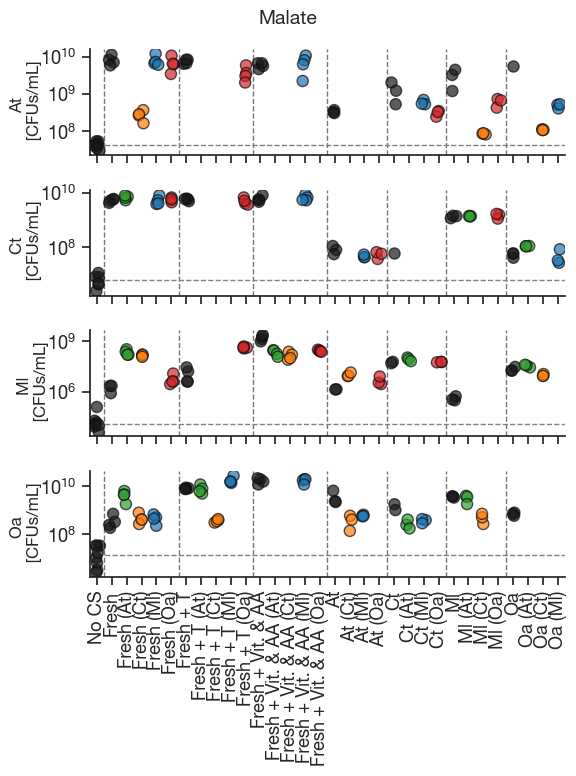

In [280]:
s = 'Oa'
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [2, 4,5, 6]
# print(sn, len(sn))
order = ['No CS', 
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
         'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
         'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
         'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
         'At', 'At (Ct)', 'At (Ml)','At (Oa)',
         'Ct', 'Ct (At)', 'Ct (Ml)','Ct (Oa)',
         'Ml', 'Ml (At)', 'Ml (Ct)','Ml (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ct)','Oa (Ml)'
         ]

fig, axes = plt.subplots(4, 1, figsize=(6,8), sharex=True, sharey=False)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
    sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    # if i == 0:
    #     legend = True
    # else:
    #     legend = False
    legend = False
    ax.set_yscale('log')
    # sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
    #                 order = order,
    #                 # hue='Partner',palette=partner_palette, 
    #                 ax=ax,
    #                 color = 'w',
    #                 fliersize=0,
    #                 linewidth=1.5,)  
    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    hue='Partner',palette=partner_palette, 
                    hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 8,
                    alpha=0.7,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    
    ax.set_ylabel(f'{s} \n [CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # Rotate x-axis labels
    ax.set_xlabel('')
    if i == 3:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5, 27.5]:
        ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    sns.despine(fig, ax=ax)
# ax.set_title(f'{s} - {cs}')
fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)

plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{cs}.pdf', bbox_inches='tight')

## Mannose

28


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/2614116191.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees


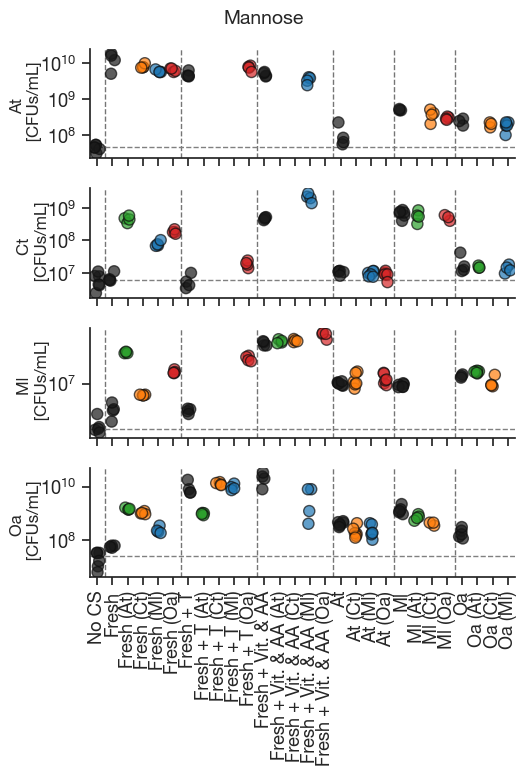

In [281]:
cs = 'Mannose'
bcs = [cs, 'No CS']
plates = [2,5]
# print(sn, len(sn))
order = ['No CS', 
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
         'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
         'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
         'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
         'At', 'At (Ct)', 'At (Ml)','At (Oa)',
        #  'Ct', 'Ct (At)', 'Ct (Ml)','Ct (Oa)',
         'Ml', 'Ml (At)', 'Ml (Ct)','Ml (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ct)','Oa (Ml)'
         ]

fig, axes = plt.subplots(4, 1, figsize=(5.5,8), sharex=True, sharey=False)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
    sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    legend = False
    # if i == 0:
    #     legend = True
    # else:
    #     legend = False
    ax.set_yscale('log')
    # sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
    #                 order = order,
    #                 # hue='Partner',palette=partner_palette, 
    #                 ax=ax,
    #                 color = 'w',
    #                 fliersize=0,
    #                 linewidth=1.5,)  
    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    hue='Partner',palette=partner_palette, 
                    hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 8,
                    alpha=0.7,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    
    ax.set_ylabel(f'{s} \n [CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # Rotate x-axis labels
    ax.set_xlabel('')
    if i == 3:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5]:
        ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    sns.despine(fig, ax=ax)
# ax.set_title(f'{s} - {cs}')
fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)

plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{cs}.pdf', bbox_inches='tight')

# Mannose interactions spent only

In [282]:
df

,Well,Plate,CFUs/mL,Species,Inoculated species,Medium,Initial OD,spent,fn,Base carbon source,Short name,Background,Partner
0,B10,2,2.000000e+08,At,At+Ct,Ml_mannose,0.001,True,cfus_spent_mannose,Mannose,Ml (Ct),Ml,Ct
1,C11,2,3.000000e+08,At,At+Oa,Ml_mannose,0.001,True,cfus_spent_mannose,Mannose,Ml (Oa),Ml,Oa
2,D1,2,5.200000e+08,At,At,Ct_isoleucine,0.001,True,cfus_spent_mannose,Isoleucine,Ct,Ct,No partner
3,D4,2,2.600000e+08,At,At+Ml,Ct_isoleucine,0.001,True,cfus_spent_mannose,Isoleucine,Ct (Ml),Ct,Ml
4,D5,2,3.000000e+08,At,At+Oa,Ct_isoleucine,0.001,True,cfus_spent_mannose,Isoleucine,Ct (Oa),Ct,Oa
...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,G8,6,7.800000e+09,Oa,Oa,M9_malate+thiamine,NaN,False,cfus_fresh_malate,Malate,Fresh + T,Fresh (monoculture),No partner
651,G12,6,1.600000e+10,Oa,Oa,M9_malate+thiamine+biotin+cysteine+proline,NaN,False,cfus_fresh_malate,Malate,Fresh + Vit. & AA,Fresh (monoculture),No partner
652,H4,6,3.200000e+08,Oa,Oa,M9_malate,NaN,False,cfus_fresh_malate,Malate,Fresh,Fresh (monoculture),No partner
653,H8,6,7.800000e+09,Oa,Oa,M9_malate+thiamine,NaN,False,cfus_fresh_malate,Malate,Fresh + T,Fresh (monoculture),No partner


# All species spent only


5


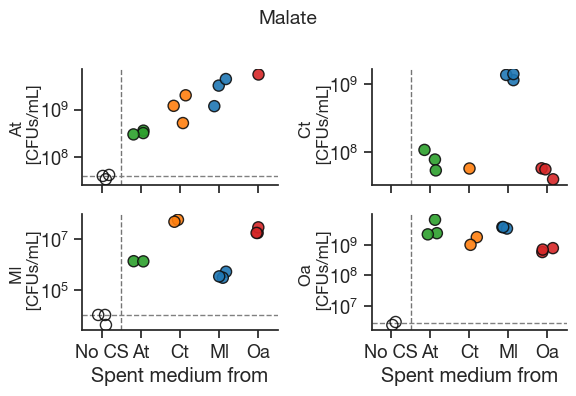

In [283]:
cs = 'Malate'
bcs = [cs, 'No CS']
plates = [4,6]
# print(sn, len(sn))
order = ['No CS', 
        #  'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
        #  'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
        #  'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
        #  'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
         'At', #'At (Ct)', 'At (Ml)','At (Oa)',
         'Ct', #'Ct (At)', 'Ct (Ml)','Ct (Oa)',
         'Ml', #'Ml (At)', 'Ml (Ct)','Ml (Oa)',
         'Oa', #'Oa (At)', 'Oa (Ct)','Oa (Ml)'
         ]

fig, axes = plt.subplots(2, 2, figsize=(6,4), sharex=True, sharey=False)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
    sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    # if i == 0:
    #     legend = True
    # else:
    #     legend = False
    legend = False
    ax.set_yscale('log')
    # sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
    #                 order = order,
    #                 # hue='Partner',palette=partner_palette, 
    #                 ax=ax,
    #                 color = 'w',
    #                 fliersize=0,
    #                 linewidth=1.5,)  
    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    hue='Short name',palette=partner_palette, 
                    hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 8,
                    alpha=0.9,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    
    # ax.set_ylabel(f'[CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # ax.set_title(f'{s}', fontsize=14)
    ax.set_ylabel(f'{s} \n [CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # Rotate x-axis labels
    ax.set_xlabel('Spent medium from')
    # if i == 3:
    #     ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    # for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5, 27.5]:
    #     ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    ax.axvline(x=0.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    sns.despine(fig, ax=ax)
# ax.set_title(f'{s} - {cs}')
fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)

plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.pdf', bbox_inches='tight')
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.png', bbox_inches='tight', dpi=300)

In [284]:
# Calc fold change
for s in species_list:
    idx = (df['Species']==s)
    df.loc[idx, 'log2 fold change'] = np.log2(df.loc[idx, 'CFUs/mL']/inoculum_cfus[s])
    df.loc[idx, 'log10 fold change'] = np.log10(df.loc[idx, 'CFUs/mL']/inoculum_cfus[s])

In [285]:
tab10 = sns.color_palette('tab10')
cs_palette = {'No CS': 'w', 'Malate': tab10[4],'Mannose': tab10[8], 'Isoleucine': tab10[6]}

In [286]:
partner_palette

{'At': (0.17254901960784313, 0.6274509803921569, 0.17254901960784313),
 'Ct': (1.0, 0.4980392156862745, 0.054901960784313725),
 'Oa': (0.8392156862745098, 0.15294117647058825, 0.1568627450980392),
 'Ml': (0.12156862745098039, 0.4666666666666667, 0.7058823529411765),
 'No partner': 'k'}

5


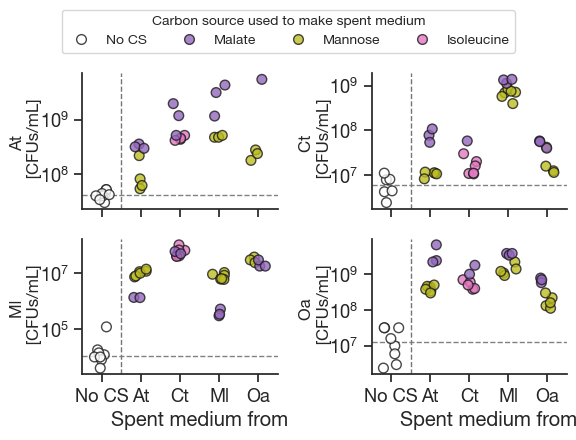

In [287]:
cs = 'Mannose'
bcs = ['Malate', cs, 'Isoleucine', 'No CS']
plates = [2, 4]
# print(sn, len(sn))
order = ['No CS', 
        #  'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
        #  'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
        #  'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
        #  'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
         'At', #'At (Ct)', 'At (Ml)','At (Oa)',
         'Ct', #'Ct (At)', 'Ct (Ml)','Ct (Oa)',
         'Ml', #'Ml (At)', 'Ml (Ct)','Ml (Oa)',
         'Oa', #'Oa (At)', 'Oa (Ct)','Oa (Ml)'
        #  'Ct'
         ]

fig, axes = plt.subplots(2, 2, figsize=(6,4), sharex=True, sharey=False)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(species_list):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
    # sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    if i == 3:
        legend = True
    else:
        legend = False
    # legend = False
    ax.set_yscale('log')

    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    # hue='Short name',
                    hue = 'Base carbon source',
                    palette=cs_palette,
                    hue_order=['No CS', 'Malate', 'Mannose','Isoleucine'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 7,
                    edgecolor='k',
                    alpha=0.8,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    
    # ax.set_ylabel(f'[CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # ax.set_title(f'{s}', fontsize=14)
    ax.set_ylabel(f'{s} \n [CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # Rotate x-axis labels
    ax.set_xlabel('Spent medium from', x = 0.6)
    # if i == 3:
    #     ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    # for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5, 27.5]:
    #     ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    ax.axvline(x=0.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    sns.despine(fig, ax=ax)
# ax.set_title(f'{s} - {cs}')
# fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)

# Add legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=True, title = "Carbon source used to make spent medium", title_fontsize=10, fontsize=10)
# Remove legend from last subplot
axes[3].get_legend().remove()

plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.pdf', bbox_inches='tight')
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.png', bbox_inches='tight', dpi=300)

5
At 0.004434830333417349
          At        Ct        Ml        Oa
At  1.000000  0.017227  0.006143  0.331361
Ct  0.017227  1.000000  0.528615  0.307991
Ml  0.006143  0.528615  1.000000  0.152491
Oa  0.331361  0.307991  0.152491  1.000000
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

At vs. Ct: Custom statistical test, P_val:1.723e-02
At vs. Ml: Custom statistical test, P_val:6.143e-03
At vs. Oa: Custom statistical test, P_val:3.314e-01
Ct 0.00023469317053931142
          At        Ct        Ml        Oa
At  1.000000  0.906324  0.000658  0.579020
Ct  0.906324  1.000000  0.000658  0.579020
Ml  0.000658  0.000658  1.000000  0.008644
Oa  0.579020  0.579020  0.008644  1.000000
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
   

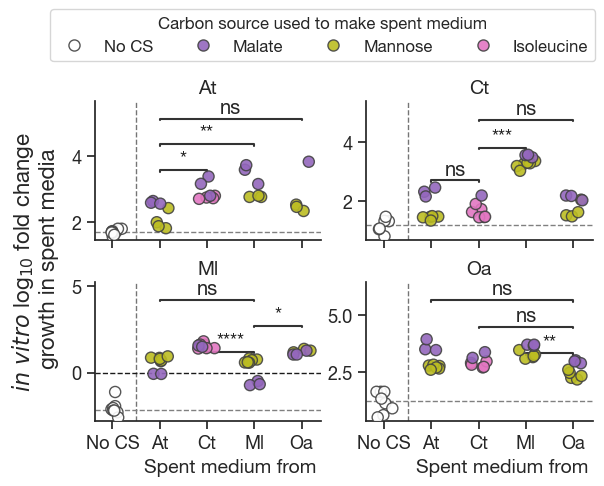

In [288]:
cs = 'Mannose'
bcs = ['Malate', cs, 'Isoleucine', 'No CS']
plates = [2, 4]
# print(sn, len(sn))
order = ['No CS', 
        #  'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
        #  'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
        #  'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
        #  'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
         'At', #'At (Ct)', 'At (Ml)','At (Oa)',
         'Ct', #'Ct (At)', 'Ct (Ml)','Ct (Oa)',
         'Ml', #'Ml (At)', 'Ml (Ct)','Ml (Oa)',
         'Oa', #'Oa (At)', 'Oa (Ct)','Oa (Ml)'
        #  'Ct'
         ]

fig, axes = plt.subplots(2, 2, figsize=(6,4), sharex=True, sharey=False)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates)&(df.Partner =='No partner'))
    # sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    if i == 3:
        legend = True
    else:
        legend = False

    df_stats = df.loc[sidx]
    df_stats = df_stats.loc[df_stats['Base carbon source'] != 'No CS']
    # Kruskal-Wallis test across all groups
    groups = [group['log10 fold change'].values for name, group in df_stats.groupby('Short name')]
    h_stat, p_value = st.kruskal(*groups)
    print(s, p_value)
    dunn_df = posthoc_dunn(df_stats, val_col="log10 fold change", group_col="Short name", p_adjust="fdr_bh")
    print(dunn_df)
    # molten_df = 
    # remove = np.tril(np.ones(dunn_df.shape), k=0).astype("bool")
    # dunn_df[remove] = np.nan

    # molten_df = dunn_df.melt(ignore_index=False).reset_index().dropna()

    pairs = [(s, x) for x in species_list if x!= s]
    p_values = [dunn_df.loc[s,x] for (s,x) in pairs]

    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'log10 fold change',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    # hue='Short name',
                    hue = 'Base carbon source',
                    # palette=partner_palette, 
                    palette = cs_palette,
                    hue_order=['No CS', 'Malate', 'Mannose','Isoleucine'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 8,
                    alpha=0.9,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    annotator = Annotator(
    ax, pairs, data=df.loc[sidx], x="Short name", y="log10 fold change", order=order, #orient="h" 
    )
    # plt.ylim(0,2)
    annotator.configure(text_format="star", loc="inside",
        hide_non_significant=False)
    annotator.set_pvalues_and_annotate(p_values)

    
    # ax.set_ylabel(f'[log2 fold change]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    ax.set_title(f'{s}', fontsize=14)
    ax.set_ylabel('')#(f'{s} \n [log2 fold change]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # Rotate x-axis labels
    ax.set_xlabel('Spent medium from', x = 0.6, fontsize=14)
    # if i == 3:
    #     ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    # for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5, 27.5]:
    #     ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    ax.axvline(x=0.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'log10 fold change'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    if df.loc[sidx, 'log10 fold change'].min() < 0:
        ax.axhline(y=0, color='k', linestyle='--', linewidth=1, zorder = 0)
    sns.despine(fig, ax=ax)
    # ax.set
# ax.set_title(f'{s} - {cs}')
fig.supylabel(r'$\mathit{in\ vitro}$ log$_{10}$ fold change' + f'\n growth in spent media', fontsize = 16, ha='center', va='center', x = 0.02)


# Add legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=True, title = "Carbon source used to make spent medium", title_fontsize=12, fontsize=12)
# Remove legend from last subplot
axes[3].get_legend().remove()

plt.subplots_adjust(top=0.9, bottom=0.1, left=0.12, right=0.95, hspace=0.3)
plt.savefig(figure_folder / f'cfus_{cs}_spent_only_stats.pdf', bbox_inches='tight')
plt.savefig(figure_folder / f'cfus_{cs}_spent_only_stats.png', bbox_inches='tight', dpi=300)

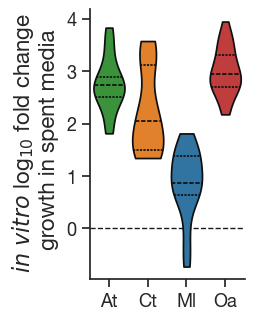

In [289]:
bcs = ['Malate', 'Mannose', 'Isoleucine']
plates = [2, 4]
idx = (df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates)&(df.Partner =='No partner'))
fig, ax = plt.subplots(figsize=(2,3.5))
sns.violinplot(data = df.loc[idx], x = 'Species', y = 'log10 fold change', palette = partner_palette, hue = 'Species', inner='quartile', ax = ax, cut = 0)
ax.set_xlabel('')
ax.set_ylabel('')
fig.supylabel(r'$\mathit{in\ vitro}$ log$_{10}$ fold change' + f'\n growth in spent media', fontsize = 16, ha='center', va='center', x = -0.15)
ax.axhline(y=0, color='k', linestyle='--', linewidth=1, zorder = 0)
sns.despine()
plt.savefig(figure_folder / f'fold_change_spent_violin.pdf', bbox_inches='tight')

plt.show()

5
At: Self vs Others p-value = 1.8369e-03
Ct: Self vs Others p-value = 5.2665e-02
Ml: Self vs Others p-value = 5.3849e-04
Oa: Self vs Others p-value = 4.9766e-03


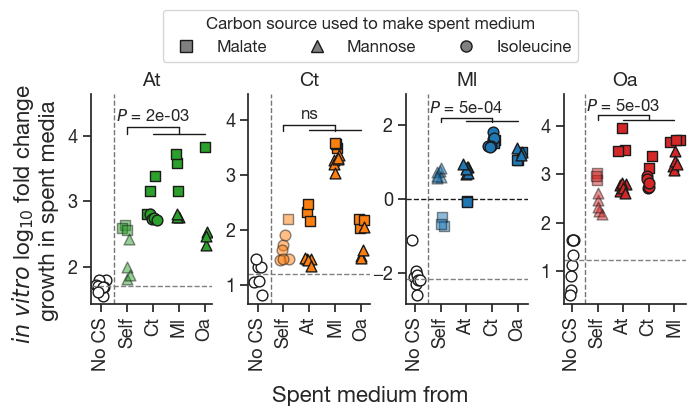

In [290]:
bcs = ['Malate', 'Mannose', 'Isoleucine', 'No CS']
plates = [2, 4]

# Define marker styles for each carbon source
cs_markers = {
    'No CS': 'o',
    'Malate': 's',      # square
    'Mannose': '^',     # triangle up
    'Isoleucine': 'o'   # triangle down
}

order = ['No CS', 
         'At', 
         'Ct', 
         'Ml', 
         'Oa', 
         ]

fig, axes = plt.subplots(1, 4, figsize=(7,3), sharex=False, sharey=False)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates)&(df.Partner =='No partner'))
    ax = axes[i]
    if i == 3:
        legend = True
    else:
        legend = False
    
    order = ['No CS', s] + [x for x in ['At', 'Ct', 'Ml', 'Oa'] if x != s]
    # Plot each carbon source with different markers
    for cs in bcs:
        dfs_cs = df.loc[sidx & (df['Base carbon source'] == cs)]
        if len(dfs_cs) > 0:
            for j, sn in enumerate(order):
                if sn == 'No CS':
                    c = 'w'
                else:
                    c = partner_palette.get(s, 'k')
                if sn == s:
                    alpha = 0.5
                    lw = 1
                else: 
                    alpha = 1
                    lw = 1
                
                dfs_sn = dfs_cs[dfs_cs['Short name'] == sn]
                if len(dfs_sn) > 0:
                    y_vals = dfs_sn['log10 fold change'].values
                    x_vals = np.random.normal(j, 0.1, len(y_vals))  # jitter
                    ax.scatter(x_vals, y_vals, marker=cs_markers[cs], 
                              color=c, 
                              s=60, alpha=alpha, edgecolor='k', linewidth=lw,
                              label=cs if (i==3 and j==0) else '')
    
    ax.set_title(f'{s}', fontsize=14, y = 1)
    ax.set_ylabel('')
    ax.set_xlabel('')#Spent medium from', x = 0.6, fontsize=14)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels([x if x!= s else 'Self' for x in order])
    ax.minorticks_off()
    ax.axvline(x=0.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'log10 fold change'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    if df.loc[sidx, 'log10 fold change'].min() < 0:
        ax.axhline(y=0, color='k', linestyle='--', linewidth=1, zorder = 0)
    sns.despine(fig, ax=ax)


    df_stats = df.loc[sidx & (df['Base carbon source'] != 'No CS')].copy()
    self_data = df_stats.loc[df_stats['Short name'] == s, 'log10 fold change'].values
    others_data = df_stats.loc[df_stats['Short name'] != s, 'log10 fold change'].values
    
    if len(self_data) > 0 and len(others_data) > 0:
        stat, p_val = st.mannwhitneyu(self_data, others_data, alternative='two-sided')
        
        # Format p-value as stars
        if p_val > 0.05:
            p_text = 'ns'
        else:
            p_text = f'$P$ = {p_val:.0e}'
        
        # Draw bracket manually
        y_max = df_stats['log10 fold change'].max()
        y_min = df_stats['log10 fold change'].min()
        y_range = y_max - y_min
        bracket_y = y_max + 0.15 * y_range
        
        # Position 1 is Self, positions 2-4 are Others
        x_start = 1
        x_end = len(order) - 2
        
        # Draw horizontal line
        ax.plot([x_start, x_end], [bracket_y, bracket_y], 'k-', linewidth=1)
        ax.plot([x_end-1, x_end+1], [bracket_y-0.1, bracket_y-0.1], 'k-', linewidth=1)
        # Draw vertical ticks
        ax.plot([x_start, x_start], [bracket_y - 0.05 * y_range, bracket_y], 'k-', linewidth=1)
        ax.plot([x_end, x_end], [bracket_y - 0.05 * y_range, bracket_y], 'k-', linewidth=1)
        # Add text
        ax.text((x_start + x_end) / 2, bracket_y + 0.02 * y_range, p_text, 
               ha='center', va='bottom', fontsize=12)
        ax.set_ylim(top = y_max + 0.4 * y_range)
        print(f'{s}: Self vs Others p-value = {p_val:.4e}')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
fig.supylabel(r'$\mathit{in\ vitro}$ log$_{10}$ fold change' + f'\n growth in spent media', fontsize = 16, ha='center', va='center', x = 0.02)
fig.supxlabel('Spent medium from', fontsize=16, x = 0.5, y = -0.14)
# Create legend for carbon sources with markers
if legend:
    legend_elements = [plt.Line2D([0], [0], marker=cs_markers[cs], color='w', 
                                 markerfacecolor='gray', markeredgecolor='k', 
                                 markersize=8, label=cs) for cs in bcs if cs != 'No CS' ]
    fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 0.98), 
               ncol=4, frameon=True, title = "Carbon source used to make spent medium", 
               title_fontsize=12, fontsize=12)

plt.subplots_adjust(top=0.9, bottom=0.2, left=0.1, right=0.95, hspace=0.4, wspace = 0.3)
plt.savefig(figure_folder / f'cfus_{cs}_spent_only_markers.pdf', bbox_inches='tight')
plt.savefig(figure_folder / f'cfus_{cs}_spent_only_markers.png', bbox_inches='tight', dpi=300)

5


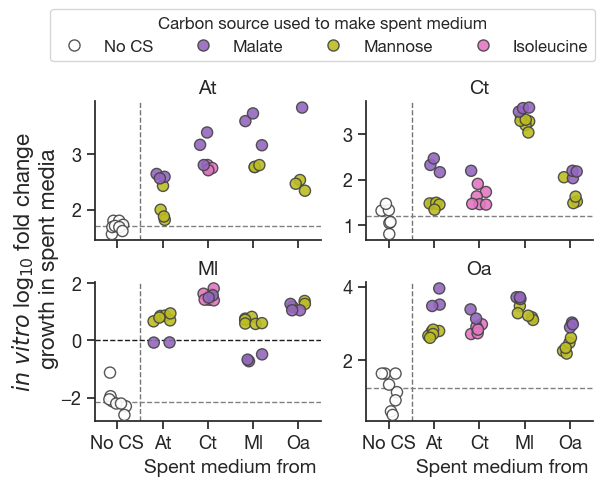

In [291]:
bcs = ['Malate', 'Mannose', 'Isoleucine', 'No CS']
plates = [2, 4]
# print(sn, len(sn))
order = ['No CS', 
         'At', #'At (Ct)', 'At (Ml)','At (Oa)',
         'Ct', #'Ct (At)', 'Ct (Ml)','Ct (Oa)',
         'Ml', #'Ml (At)', 'Ml (Ct)','Ml (Oa)',
         'Oa', #'Oa (At)', 'Oa (Ct)','Oa (Ml)'
         ]

fig, axes = plt.subplots(2, 2, figsize=(6,4), sharex=True, sharey=False)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates)&(df.Partner =='No partner'))
    # sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    if i == 3:
        legend = True
    else:
        legend = False
    # legend = False
    # ax.set_yscale('log')
    # sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
    #                 order = order,
    #                 # hue='Partner',palette=partner_palette, 
    #                 ax=ax,
    #                 color = 'w',
    #                 fliersize=0,
    #                 linewidth=1.5,)  
    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'log10 fold change',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    # hue='Short name',
                    hue = 'Base carbon source',
                    # palette=partner_palette, 
                    palette = cs_palette,
                    hue_order=['No CS', 'Malate', 'Mannose','Isoleucine'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 8,
                    alpha=0.9,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    
    # ax.set_ylabel(f'[log2 fold change]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    ax.set_title(f'{s}', fontsize=14)
    ax.set_ylabel('')#(f'{s} \n [log2 fold change]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    # Rotate x-axis labels
    ax.set_xlabel('Spent medium from', x = 0.6, fontsize=14)
    # if i == 3:
    #     ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    # for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5, 27.5]:
    #     ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    ax.axvline(x=0.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'log10 fold change'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    if df.loc[sidx, 'log10 fold change'].min() < 0:
        ax.axhline(y=0, color='k', linestyle='--', linewidth=1, zorder = 0)
    sns.despine(fig, ax=ax)
    # ax.set
# ax.set_title(f'{s} - {cs}')
fig.supylabel(r'$\mathit{in\ vitro}$ log$_{10}$ fold change' + f'\n growth in spent media', fontsize = 16, ha='center', va='center', x = 0.02)


# Add legend
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0.98), ncol=4, frameon=True, title = "Carbon source used to make spent medium", title_fontsize=12, fontsize=12)
# Remove legend from last subplot
axes[3].get_legend().remove()

plt.subplots_adjust(top=0.9, bottom=0.1, left=0.12, right=0.95, hspace=0.3)
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.pdf', bbox_inches='tight')
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.png', bbox_inches='tight', dpi=300)

## Compare growth in self vs others

5
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Own vs. Others: Mann-Whitney-Wilcoxon test two-sided, P_val:1.837e-03 U_stat=1.000e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Own vs. Others: Mann-Whitney-Wilcoxon test two-sided, P_val:5.267e-02 U_stat=4.250e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Own vs. Others: Mann-Whitney-Wilcoxon test two-sided, P_val:5.385e-04 U_stat=1.900e+01
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.0

/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/302465924.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Self', 'Partners'], rotation=90, ha='center', va='top')
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/302465924.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Self', 'Partners'], rotation=90, ha='center', va='top')
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/302465924.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Self', 'Partners'], rotation=90, ha='center', va='top')
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_14210/302465924.py:38: UserWarning: set_ticklabels() should only be used w

(-1.0, 5.0)

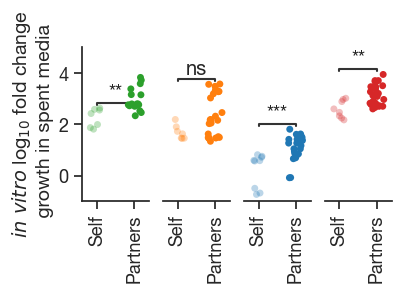

In [292]:
bcs = ['Malate', 'Mannose', 'Isoleucine']
plates = [2, 4]
fig, axes = plt.subplots(1, 4, figsize=(4,2), sharex=False, sharey=True)
print(len(order))

axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    ax = axes[i]
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates)&(df.Partner =='No partner'))
    dfs = df.loc[sidx].copy()
    dfs.loc[dfs.Background == s, 'Own / others'] = 'Own'
    dfs.loc[dfs.Background != s, 'Own / others'] = 'Others'
    
    # Plot "Others" first with alpha=1
    dfs_others = dfs[dfs['Own / others'] == 'Others']
    if len(dfs_others) > 0:
        sns.stripplot(data=dfs_others, x='Own / others', y='log10 fold change', ax=ax, 
                     hue='Species', palette=partner_palette, legend=False, 
                     order=['Own', 'Others'], alpha=1, jitter=0.2)
    
    # Plot "Own" second with alpha=0.3
    dfs_own = dfs[dfs['Own / others'] == 'Own']
    if len(dfs_own) > 0:
        sns.stripplot(data=dfs_own, x='Own / others', y='log10 fold change', ax=ax, 
                     hue='Species', palette=partner_palette, legend=False, 
                     order=['Own', 'Others'], alpha=0.3, jitter=0.2)
    
    # Add statistical annotation
    pairs = [('Own', 'Others')]
    annotator = Annotator(ax, pairs, data=dfs, x='Own / others', y='log10 fold change', order=['Own', 'Others'])
    annotator.configure(test='Mann-Whitney', text_format='star', loc='inside')
    annotator.apply_and_annotate()
    
    ax.set_xlabel('')
    ax.set_xlim(-0.4, 1.4)
    
    # ax.set_xticks([0.5])
    ax.set_xticklabels(['Self', 'Partners'], rotation=90, ha='center', va='top')
    if i == 0:
        sns.despine(ax=ax, left=False)
        ax.set_ylabel('')
    else:
        sns.despine(ax=ax, left=True)
        ax.set_ylabel('')
        ax.tick_params(left=False, labelleft=False)
fig.supylabel(r'$\mathit{in\ vitro}$ log$_{10}$ fold change' + f'\n growth in spent media', fontsize = 14, ha='center', va='center', x = 0.0)

plt.ylim(-1, 5)

Median n1: 1.9, Median n2: 2.7
scipy mannwhitneyu: U1=804.5, U2=1892.5, U_min=804.5, p=0.000889100180713801
n1=31, n2=87, n1*n2=2697
Z-score (from U_min) = -3.3264
P-value from Z (two-sided): 0.000880
Self vs. Partners: Mann-Whitney-Wilcoxon test two-sided, P_val:8.891e-04 U_stat=8.045e+02


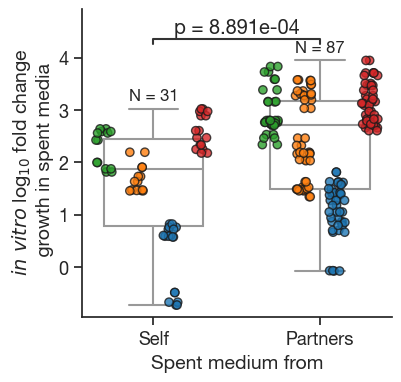

In [294]:
bcs = ['Malate', 'Mannose', 'Isoleucine']
idx = (df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates)&(df.Partner =='No partner'))
dfi = df.loc[idx].copy()

dfi.loc[df['Short name']==df['Species'], 'Own / Partners'] = 'Self'
dfi.loc[df['Short name']!=df['Species'], 'Own / Partners'] = 'Partners'

fig, ax = plt.subplots(1, figsize = (4,4))
sns.boxplot(data = dfi, x = 'Own / Partners', y = 'log10 fold change', ax = ax, color = 'w', order = ['Self', 'Partners'], width = 0.6, linewidth = 1.5)
g = sns.stripplot(data = dfi, x = 'Own / Partners', y = 'log10 fold change', ax = ax, hue = 'Species', 
                    palette=partner_palette, legend = False, order = ['Self', 'Partners'], alpha = 0.8, jitter= 0.2, edgecolor = 'k', linewidth = 1, s = 6, dodge = True)
g = sns.stripplot(data = dfi, x = 'Own / Partners', y = 'log10 fold change', ax = ax, hue = 'Species', 
                    palette=partner_palette, legend = False, order = ['Self', 'Partners'], alpha = 0.8, jitter= 0.2, edgecolor = 'k', linewidth = 1, s = 6, dodge = True)

# Calculate and display N for each group
test_values = []
for _, (g, values) in enumerate(dfi.groupby('Own / Partners')):
    n = len(values)
    y_max = values['log10 fold change'].max()
    if g == 'Self':
        i = 0
    else:
        i = 1
    ax.text(i, y_max + 0.1, f'N = {n}', ha='center', va='bottom', fontsize=12)
    test_values.append(values['log10 fold change'])

# Add p-value annotation using Annotator
test_values = [test_values[1], test_values[0]]
u_stat, p_value = st.mannwhitneyu(*test_values, alternative='two-sided')
n1 = len(test_values[0])
n2 = len(test_values[1])

# Calculate both U statistics
u1 = u_stat
u2 = n1 * n2 - u_stat
u_min = min(u1, u2)

# Calculate Z-score from U statistic (using minimum U)
mu_U = n1 * n2 / 2
sigma_U = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
z_score = (u_min - mu_U) / sigma_U

print(f"Median n1: {np.median(test_values[0]):.1f}, Median n2: {np.median(test_values[1]):.1f}")
print(f"scipy mannwhitneyu: U1={u1}, U2={u2}, U_min={u_min}, p={p_value}")
print(f"n1={n1}, n2={n2}, n1*n2={n1*n2}")
print(f"Z-score (from U_min) = {z_score:.4f}")
print(f"P-value from Z (two-sided): {2 * (1 - st.norm.cdf(abs(z_score))):.6f}")

pairs = [('Self', 'Partners')]
annotator = Annotator(ax, pairs, data=dfi, x='Own / Partners', y='log10 fold change', order=['Self', 'Partners'])
annotator.configure(test='Mann-Whitney', text_format='full', loc='inside', show_test_name = False)
annotator.apply_and_annotate()
# print(f"Annotator test_result: {annotator.test_result_list}")
# Custom format p-value text
# plt.subplots_adjust(left = 0.1)
fig.supylabel(r'$\mathit{in\ vitro}$ log$_{10}$ fold change' + f'\n growth in spent media', fontsize = 14, ha='center', va='center', x = 0.0)
ax.set_xlabel('Spent medium from', fontsize = 14)
ax.set_ylabel('')
sns.despine()

plt.savefig(figure_folder / 'self_vs_spent.pdf', bbox_inches = 'tight')

# Export

In [295]:
# Create summary dataframe
summary_data = []

for species in df['Species'].unique():
    for m in df['Medium'].unique():
        for spent in [True, False]:
            for bg in df['Background'].unique():
                for partner in df['Partner'].unique():
                    # Filter data
                    idx = (df['Species'] == species) & \
                        (df['Medium'] == m) & \
                        (df['spent'] == spent) &\
                        (df['Background'] == bg)&\
                        (df['Partner'] == partner)
                    
                    subset = df.loc[idx]
                    if len(subset) > 6:
                        print(df.loc[idx])
                    
                    if len(subset) > 0:
                        summary_data.append({
                            'Species': species,
                            'Carbon source': cs,
                            'Spent': spent,
                            'Medium': m,
                            'Spent media from': bg,
                            'Partner': partner,
                            'N samples': len(subset),
                            'Mean CFUs/mL': subset['CFUs/mL'].mean(),
                            'Median CFUs/mL': subset['CFUs/mL'].median(),
                            'Std CFUs/mL': subset['CFUs/mL'].std(),
                            'Min CFUs/mL': subset['CFUs/mL'].min(),
                            'Max CFUs/mL': subset['CFUs/mL'].max(),
                        })

summary_df = pd.DataFrame(summary_data)

# Sort by species and carbon source
summary_df = summary_df.sort_values(['Species', 'Carbon source', 'Spent']).reset_index(drop=True)

# Save to CSV
summary_df.to_csv(folder / 'conditions_summary.csv', index=False)

# Display
print(f"Summary saved with {len(summary_df)} rows")
summary_df.head(20)

    Well  Plate     CFUs/mL Species Inoculated species Medium  Initial OD  \
10    G1      2  44000000.0      At                 At  No CS       0.001   
11    G2      2  52000000.0      At                 At  No CS       0.001   
12    G3      2  52000000.0      At                 At  No CS       0.001   
114   G1      2  30000000.0      At                 At  No CS       0.001   
115   G2      2  40000000.0      At                 At  No CS       0.001   
116   G3      2  44000000.0      At                 At  No CS       0.001   
401   E1      4  42000000.0      At                 At  No CS         NaN   
402   E2      4  40000000.0      At                 At  No CS         NaN   
403   E3      4  34000000.0      At                 At  No CS         NaN   

     spent                  fn Base carbon source Short name Background  \
10    True  cfus_spent_mannose              No CS      No CS      No CS   
11    True  cfus_spent_mannose              No CS      No CS      No CS   
12  

,Species,Carbon source,Spent,Medium,Spent media from,Partner,N samples,Mean CFUs/mL,Median CFUs/mL,Std CFUs/mL,Min CFUs/mL,Max CFUs/mL
0,At,No CS,False,Ct_isoleucine,Ct,No partner,3,1.866667e+09,1.800000e+09,3.055050e+08,1.600000e+09,2.200000e+09
1,At,No CS,False,No CS,No CS,No partner,3,3.266667e+08,3.200000e+08,9.018500e+07,2.400000e+08,4.200000e+08
2,At,No CS,False,M9_mannose,Fresh (coculture),Ct,4,8.100000e+09,7.600000e+09,1.137248e+09,7.400000e+09,9.800000e+09
3,At,No CS,False,M9_mannose,Fresh (coculture),Oa,4,6.400000e+09,6.500000e+09,7.118052e+08,5.600000e+09,7.000000e+09
4,At,No CS,False,M9_mannose,Fresh (coculture),Ml,4,5.850000e+09,5.600000e+09,5.000000e+08,5.600000e+09,6.600000e+09
5,At,No CS,False,M9_mannose,Fresh (monoculture),No partner,4,1.275000e+10,1.400000e+10,5.737305e+09,5.000000e+09,1.800000e+10
6,At,No CS,False,M9_mannose+thiamine,Fresh (coculture),Oa,4,7.300000e+09,7.600000e+09,1.205543e+09,5.600000e+09,8.400000e+09
7,At,No CS,False,M9_mannose+thiamine,Fresh (monoculture),No partner,4,4.800000e+09,4.400000e+09,9.380832e+08,4.200000e+09,6.200000e+09
8,At,No CS,False,M9_mannose+thiamine+biotin+cysteine+proline,Fresh (coculture),Ml,4,3.350000e+09,3.500000e+09,7.187953e+08,2.400000e+09,4.000000e+09
9,At,No CS,False,M9_mannose+thiamine+biotin+cysteine+proline,Fresh (monoculture),No partner,4,4.850000e+09,4.800000e+09,6.608076e+08,4.200000e+09,5.600000e+09


16


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_59811/1005599340.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_59811/1005599340.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_59811/1005599340.py:58: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh

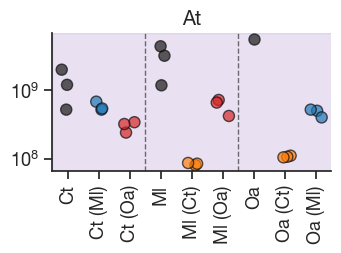

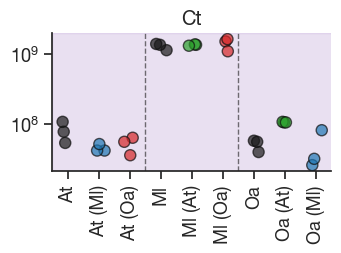

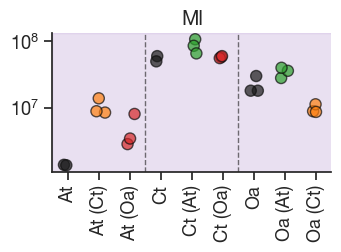

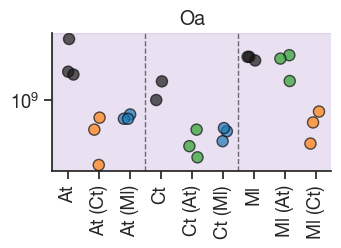

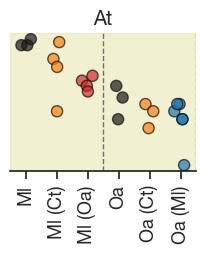

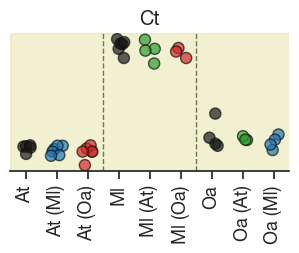

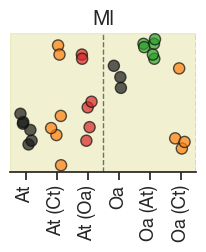

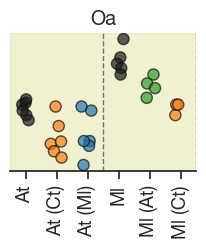

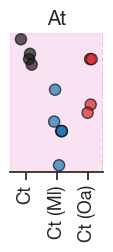

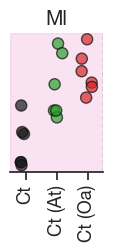

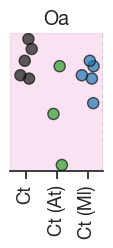

In [ ]:
# print(sn, len(sn))
order = [#'No CS', 
        #  'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
        #  'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
        #  'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
        #  'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
         'At', 'At (Ct)', 'At (Ml)','At (Oa)',
         'Ct', 'Ct (At)', 'Ct (Ml)','Ct (Oa)',
         'Ml', 'Ml (At)', 'Ml (Ct)','Ml (Oa)',
         'Oa', 'Oa (At)', 'Oa (Ct)','Oa (Ml)'
         ]


print(len(order))
# axes = axes.flatten()
plates = [2, 4,5, 6]
ylims = {
    'At': (6,13),
    'Ct': (3,13),
    'Ml': (-1,8),
    'Oa': (6,14)
}
minvals = defaultdict(lambda: 15)
maxvals = defaultdict(lambda: 0)
for j, cs in enumerate(['Malate', 'Mannose', 'Isoleucine']):
    for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
        
        sidx = (df['Species']==s)&(df['Base carbon source'] == cs)&(df['Plate'].isin(plates))&(df['spent'])&(df['Background']!=s)
        if np.sum(sidx) == 0:
            continue
        sn = df.loc[sidx, 'Short name'].unique()
        minvals[s] = min(minvals[s], df.loc[sidx, 'CFUs/mL'].min())
        maxvals[s] = max(maxvals[s], df.loc[sidx, 'CFUs/mL'].max())
        fig, ax = plt.subplots(1, 1, figsize=(len(sn)/2.5, 1.8), sharex=False, sharey=False)
        legend = False
        ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                        order = [x for x in order if not s in x and x in sn],
                        legend=legend,
                        # aspect=2, height=3, 
                        hue='Partner',palette=partner_palette, 
                        hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                        # hue = 'Base carbon source',
                        jitter=0.2,
                        ax=ax,
                        size = 8,
                        alpha=0.7,
                        linewidth=1)
        # if i != 3:
        #     ax.set(xlabel='')
        
        # ax.set_ylabel(f'{s}', rotation=90, size=12, ha='center', va='center', labelpad=10)
        # Rotate x-axis labels
        ax.set_yscale('log')
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(f'{s}')
        # if i == 3:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
        ax.minorticks_off()  # Turns off minor ticks
        for x in [2.5, 5.5]:#, 10.5, 15.5, 19.5, 23.5]:
            ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
        # if i == 0:
        #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
        no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
        ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
        ax.axvspan(-0.5, 10, color=cs_palette[cs], alpha = 0.2)
        # ax.set_ylim(ylims[s])

        ax.set_xlim(-0.5, len(sn)-0.5)
        if j == 0:
            sns.despine(fig, ax=ax)
        else:
            sns.despine(fig, ax=ax, left=True)
            ax.tick_params(left=False, labelleft=False)
        plt.savefig(figure_folder / f'cfus_{s}_{cs}_spent_fold_change.pdf', bbox_inches='tight')
    
    # plt.show()
# fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)
# fig.supylabel('CFUs/mL', fontsize=14, ha='center', va='center', x = 0)
# plt.tight_layout()
# plt.savefig(figure_folder / f'cfus_{cs}.pdf', bbox_inches='tight')

15


/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_59811/1098336742.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_59811/1098336742.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh0000gp/T/ipykernel_59811/1098336742.py:55: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
/var/folders/xf/kl76knj11y72v0_qy4vv7tgh

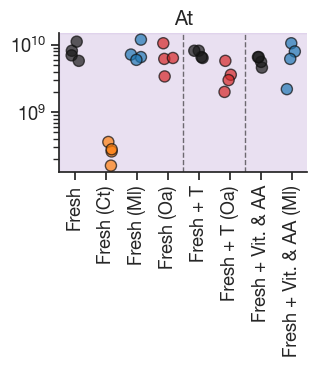

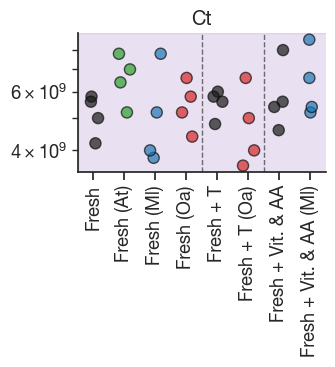

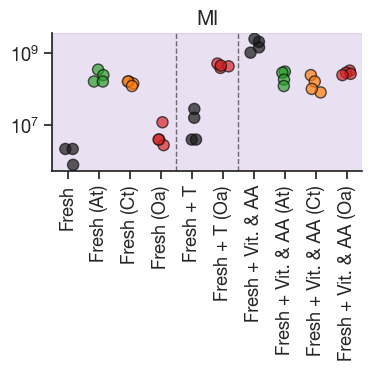

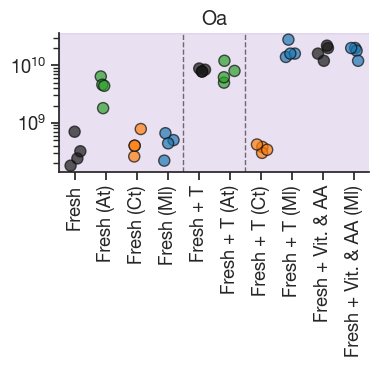

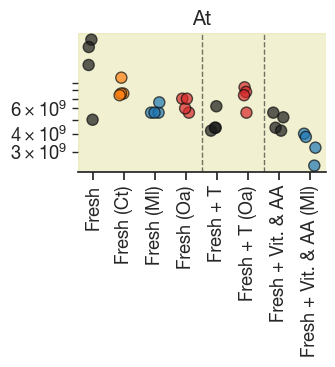

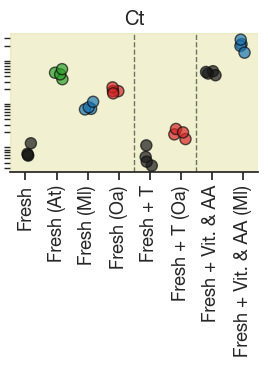

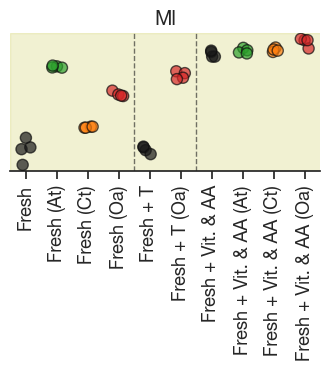

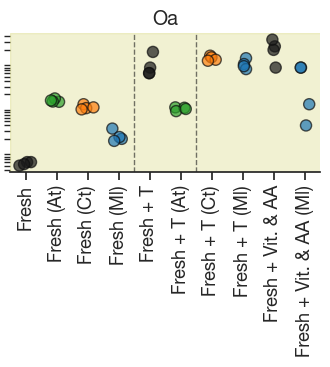

/Users/snorre/miniconda3/lib/python3.12/site-packages/matplotlib/_tight_bbox.py:67: RuntimeWarning: divide by zero encountered in scalar divide
  fig.patch.set_bounds(x0 / w1, y0 / h1,
/Users/snorre/miniconda3/lib/python3.12/site-packages/matplotlib/_tight_bbox.py:68: RuntimeWarning: divide by zero encountered in scalar divide
  fig.bbox.width / w1, fig.bbox.height / h1)
/Users/snorre/miniconda3/lib/python3.12/site-packages/matplotlib/patches.py:796: RuntimeWarning: invalid value encountered in scalar add
  x1 = self.convert_xunits(self._x0 + self._width)
/Users/snorre/miniconda3/lib/python3.12/site-packages/matplotlib/transforms.py:2035: RuntimeWarning: invalid value encountered in scalar add
  self._mtx[0, 2] += tx


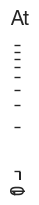

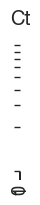

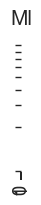

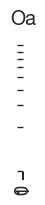

In [ ]:
# print(sn, len(sn))
order = [#'No CS', 
         'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
         'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
         'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
         'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
        #  'At', 'At (Ct)', 'At (Ml)','At (Oa)',
        #  'Ct', 'Ct (At)', 'Ct (Ml)','Ct (Oa)',
        #  'Ml', 'Ml (At)', 'Ml (Ct)','Ml (Oa)',
        #  'Oa', 'Oa (At)', 'Oa (Ct)','Oa (Ml)'
         ]


print(len(order))
# axes = axes.flatten()
plates = [2, 4,5, 6]
ylims = {
    'At': (6,15),
    'Ct': (3,15),
    'Ml': (-6,14),
    'Oa': (5,16)
}
minvals = defaultdict(lambda: 15)
maxvals = defaultdict(lambda: 0)
for j, cs in enumerate(['Malate', 'Mannose', 'Isoleucine']):
    for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
        
        sidx = (df['Species']==s)&(df['Base carbon source'] == cs)&(df['Plate'].isin(plates))&(~df['spent'])
        sn = df.loc[sidx, 'Short name'].unique()
        minvals[s] = min(minvals[s], df.loc[sidx, 'CFUs/mL'].min())
        maxvals[s] = max(maxvals[s], df.loc[sidx, 'CFUs/mL'].max())
        fig, ax = plt.subplots(1, 1, figsize=(len(sn)/2.5, 1.8), sharex=False, sharey=False)
        legend = False
        ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                        order = [x for x in order if not s in x and x in sn],
                        legend=legend,
                        # aspect=2, height=3, 
                        hue='Partner',palette=partner_palette, 
                        hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                        # hue = 'Base carbon source',
                        jitter=0.2,
                        ax=ax,
                        size = 8,
                        alpha=0.7,
                        linewidth=1)
        # if i != 3:
        #     ax.set(xlabel='')
        
        # ax.set_ylabel(f'{s}', rotation=90, size=12, ha='center', va='center', labelpad=10)
        # Rotate x-axis labels
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title(f'{s}')
        # if i == 3:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
        ax.minorticks_off()  # Turns off minor ticks
        for x in [3.5, 5.5]:#, 10.5, 15.5, 19.5, 23.5]:
            ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
        # if i == 0:
        #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
        no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
        ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
        ax.axvspan(-0.5, 10, color=cs_palette[cs], alpha = 0.2)
        # ax.set_ylim(ylims[s])
        ax.set_yscale('log')

        ax.set_xlim(-0.5, len(sn)-0.5)
        if j == 0:
            sns.despine(fig, ax=ax)
        else:
            sns.despine(fig, ax=ax, left=True)
            ax.tick_params(left=False, labelleft=False)
        plt.savefig(figure_folder / f'cfus_{s}_{cs}_fresh_fold_change.pdf', bbox_inches='tight')
    
    # plt.show()
# fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)
# fig.supylabel('CFUs/mL', fontsize=14, ha='center', va='center', x = 0)
# plt.tight_layout()
# plt.savefig(figure_folder / f'cfus_{cs}.pdf', bbox_inches='tight')

In [ ]:
from statannotations.Annotator import Annotator

df.loc[~df.spent&(df['Base carbon source']=='Isoleucine')]

,Well,Plate,CFUs/mL,Species,Inoculated species,Medium,Initial OD,spent,fn,Base carbon source,Short name,Background,Partner,log2 fold change,log10 fold change
358,A1,3,1.800000e+09,At,At,Ct_isoleucine,0.05,False,cfus_fresh_mannose,Isoleucine,Ct 2,Ct,No partner,11.089828,3.338371
359,B1,3,1.600000e+09,At,At,Ct_isoleucine,0.05,False,cfus_fresh_mannose,Isoleucine,Ct 2,Ct,No partner,10.919903,3.287218
360,B4,3,2.400000e+08,At,At,M9_isoleucine,0.05,False,cfus_fresh_mannose,Isoleucine,Fresh,Fresh (monoculture),No partner,8.182937,2.463310
361,C1,3,2.200000e+09,At,At,Ct_isoleucine,0.05,False,cfus_fresh_mannose,Isoleucine,Ct 2,Ct,No partner,11.379334,3.425521
362,C4,3,2.600000e+08,At,At,M9_isoleucine,0.05,False,cfus_fresh_mannose,Isoleucine,Fresh,Fresh (monoculture),No partner,8.298414,2.498072
366,D1,3,2.200000e+08,Ct,Ct,Ct_isoleucine,0.05,False,cfus_fresh_mannose,Isoleucine,Ct 2,Ct,No partner,9.208163,2.771933
367,D2,3,4.600000e+08,Ct,Ct,Ct_isoleucine,0.05,False,cfus_fresh_mannose,Isoleucine,Ct 2,Ct,No partner,10.272293,3.092268
368,D3,3,4.200000e+08,Ct,Ct,Ct_isoleucine,0.05,False,cfus_fresh_mannose,Isoleucine,Ct 2,Ct,No partner,10.141048,3.052760
369,D4,3,7.600000e+09,Ct,Ct,M9_isoleucine,0.05,False,cfus_fresh_mannose,Isoleucine,Fresh,Fresh (monoculture),No partner,14.318587,4.310324
370,D5,3,7.600000e+09,Ct,Ct,M9_isoleucine,0.05,False,cfus_fresh_mannose,Isoleucine,Fresh,Fresh (monoculture),No partner,14.318587,4.310324


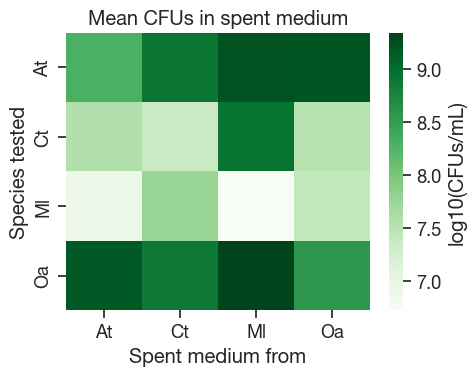

In [ ]:
# Create heatmap of CFUs in spent medium
cs = 'Mannose'
bcs = ['Malate', cs, 'Isoleucine']
plates = [2, 4]

# Filter data matching the plot above
idx = (df['Base carbon source'].isin(bcs)) & (df['Plate'].isin(plates))
df_subset = df.loc[idx].copy()

# Calculate mean CFUs/mL for each Species x Short name combination
heatmap_data = df_subset.groupby(['Species', 'Short name'])['CFUs/mL'].mean().unstack()

# Reorder to match the plot
species_order = ['At', 'Ct', 'Ml', 'Oa']
heatmap_data = heatmap_data.loc[species_order, species_order]

# Create heatmap
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(np.log10(heatmap_data), 
            annot=False, 
            fmt='.2f',
            cmap='Greens',
            cbar_kws={'label': 'log10(CFUs/mL)'},
            ax=ax)
ax.set_xlabel('Spent medium from')
ax.set_ylabel('Species tested')
ax.set_title(f'Mean CFUs in spent medium')
plt.tight_layout()
plt.savefig(figure_folder / f'cfus_spent_heatmap.pdf', bbox_inches='tight')
plt.savefig(figure_folder / f'cfus_spent_heatmap.png', bbox_inches='tight', dpi=300)

In [ ]:
df.loc[df['Short name'].isin(['No CS', ])].sort_values(by = 'Species')

,Well,Plate,CFUs/mL,Species,Inoculated species,Medium,Initial OD,spent,fn,Base carbon source,Short name,Background,Partner,log2 fold change,log10 fold change
10,G1,2,44000000.0,At,At,No CS,0.001,True,cfus_spent_mannose,No CS,No CS,No CS,No partner,5.735478,1.726551
11,G2,2,52000000.0,At,At,No CS,0.001,True,cfus_spent_mannose,No CS,No CS,No CS,No partner,5.976486,1.799102
12,G3,2,52000000.0,At,At,No CS,0.001,True,cfus_spent_mannose,No CS,No CS,No CS,No partner,5.976486,1.799102
403,E3,4,34000000.0,At,At,No CS,NaN,True,cfus_spent_malate,No CS,No CS,No CS,No partner,5.363509,1.614577
402,E2,4,40000000.0,At,At,No CS,NaN,True,cfus_spent_malate,No CS,No CS,No CS,No partner,5.597975,1.685158
401,E1,4,42000000.0,At,At,No CS,NaN,True,cfus_spent_malate,No CS,No CS,No CS,No partner,5.668364,1.706348
116,G3,2,44000000.0,At,At,No CS,0.001,True,cfus_spent_mannose,No CS,No CS,No CS,No partner,5.735478,1.726551
115,G2,2,40000000.0,At,At,No CS,0.001,True,cfus_spent_mannose,No CS,No CS,No CS,No partner,5.597975,1.685158
114,G1,2,30000000.0,At,At,No CS,0.001,True,cfus_spent_mannose,No CS,No CS,No CS,No partner,5.182937,1.560220
148,G6,2,4400000.0,Ct,Ct,No CS,0.001,True,cfus_spent_mannose,No CS,No CS,No CS,No partner,3.564306,1.072963


In [ ]:
# bcs = ['Malate', cs, 'Isoleucine', 'No CS']
# plates = [2,4, 5, 6]
# # print(sn, len(sn))
# order = ['No CS', 'At', 'Ct', 'Ml', 'Oa']
# df_spent_dist = 
# for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
#     sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))


2


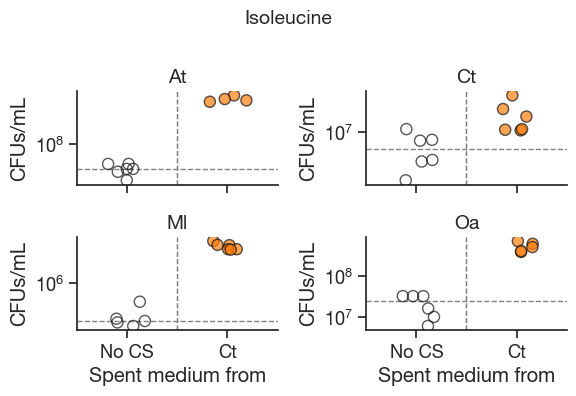

In [ ]:
cs = 'Isoleucine'
bcs = [cs, 'No CS']
plates = [2,5]
# print(sn, len(sn))
order = ['No CS', 
        #  'Fresh',  'Fresh (At)', 'Fresh (Ct)', 'Fresh (Ml)','Fresh (Oa)',
        #  'Fresh + T', 'Fresh + T (At)', 'Fresh + T (Ct)', 'Fresh + T (Ml)','Fresh + T (Oa)',
        #  'Fresh + Vit. & AA',  'Fresh + Vit. & AA (At)', 'Fresh + Vit. & AA (Ct)',
        #  'Fresh + Vit. & AA (Ml)','Fresh + Vit. & AA (Oa)',
        #  'At', #'At (Ct)', 'At (Ml)','At (Oa)',
         'Ct', #'Ct (At)', 'Ct (Ml)','Ct (Oa)',
        #  'Ml', #'Ml (At)', 'Ml (Ct)','Ml (Oa)',
        #  'Oa', #'Oa (At)', 'Oa (Ct)','Oa (Ml)'
         ]

fig, axes = plt.subplots(2, 2, figsize=(6,4), sharex=True, sharey=False)
print(len(order))
axes = axes.flatten()
for i, s in enumerate(['At', 'Ct', 'Ml', 'Oa']):
    sidx = (df['Species']==s)&(df['Base carbon source'].isin(bcs))&(df['Plate'].isin(plates))
    sn = df.loc[sidx, 'Short name'].unique()
    ax = axes[i]
    # if i == 0:
    #     legend = True
    # else:
    #     legend = False
    legend = False
    ax.set_yscale('log')
    # sns.boxplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
    #                 order = order,
    #                 # hue='Partner',palette=partner_palette, 
    #                 ax=ax,
    #                 color = 'w',
    #                 fliersize=0,
    #                 linewidth=1.5,)  
    ax = sns.stripplot(data = df.loc[sidx], x = 'Short name', y = 'CFUs/mL',
                    order = order,
                    legend=legend,
                    # aspect=2, height=3, 
                    hue='Short name',palette=partner_palette, 
                    hue_order=['At', 'Ct', 'Ml', 'Oa', 'No partner'],
                    # hue = 'Base carbon source',
                    jitter=0.2,
                    ax=ax,
                    size = 8,
                    alpha=0.7,
                    linewidth=1)
    # if i != 3:
    #     ax.set(xlabel='')
    
    # ax.set_ylabel(f'[CFUs/mL]', rotation=90, size=12, ha='center', va='center', labelpad=10)
    ax.set_title(f'{s}', fontsize=14)
    # Rotate x-axis labels
    ax.set_xlabel('Spent medium from')
    # if i == 3:
    #     ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center', va = 'top')  # Rotate labels 45 degrees
    ax.minorticks_off()  # Turns off minor ticks
    # for x in [0.5, 5.5, 10.5, 15.5, 19.5, 23.5, 27.5]:
    #     ax.axvline(x=x, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    ax.axvline(x=0.5, color='k', linestyle='--', linewidth=1, alpha = 0.6)
    # if i == 0:
    #     sns.move_legend(ax, ncol=5, bbox_to_anchor = (0,1.1)  , loc='lower left', fontsize=10)
    no_cs_mean = df.loc[sidx&(df.Medium=='No CS'), 'CFUs/mL'].median()
    ax.axhline(y=no_cs_mean, color='grey', linestyle='--', linewidth=1)
    sns.despine(fig, ax=ax)
# ax.set_title(f'{s} - {cs}')
fig.suptitle(cs, fontsize = 14, ha='center', va='bottom',y = 0.95)

plt.tight_layout()
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.pdf', bbox_inches='tight')
plt.savefig(figure_folder / f'cfus_{cs}_spent_only.png', bbox_inches='tight', dpi=300)

In [ ]:
df

,Well,Plate,CFUs/mL,Species,Inoculated species,Medium,Initial OD,spent,fn,Base carbon source,Short name,Background,Partner,log2 fold change,log10 fold change
0,B10,2,2.000000e+08,At,At+Ct,Ml_mannose,0.001,True,cfus_spent_mannose,Mannose,Ml (Ct),Ml,Ct,7.919903,2.384128
1,C11,2,3.000000e+08,At,At+Oa,Ml_mannose,0.001,True,cfus_spent_mannose,Mannose,Ml (Oa),Ml,Oa,8.504865,2.560220
2,D1,2,5.200000e+08,At,At,Ct_isoleucine,0.001,True,cfus_spent_mannose,Isoleucine,Ct,Ct,No partner,9.298414,2.799102
3,D4,2,2.600000e+08,At,At+Ml,Ct_isoleucine,0.001,True,cfus_spent_mannose,Isoleucine,Ct (Ml),Ct,Ml,8.298414,2.498072
4,D5,2,3.000000e+08,At,At+Oa,Ct_isoleucine,0.001,True,cfus_spent_mannose,Isoleucine,Ct (Oa),Ct,Oa,8.504865,2.560220
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
650,G8,6,7.800000e+09,Oa,Oa,M9_malate+thiamine,NaN,False,cfus_fresh_malate,Malate,Fresh + T,Fresh (monoculture),No partner,13.353756,4.019881
651,G12,6,1.600000e+10,Oa,Oa,M9_malate+thiamine+biotin+cysteine+proline,NaN,False,cfus_fresh_malate,Malate,Fresh + Vit. & AA,Fresh (monoculture),No partner,14.390282,4.331907
652,H4,6,3.200000e+08,Oa,Oa,M9_malate,NaN,False,cfus_fresh_malate,Malate,Fresh,Fresh (monoculture),No partner,8.746426,2.632937
653,H8,6,7.800000e+09,Oa,Oa,M9_malate+thiamine,NaN,False,cfus_fresh_malate,Malate,Fresh + T,Fresh (monoculture),No partner,13.353756,4.019881


# Save data


In [ ]:
df.to_csv(folder/'all_interactions_cfus.csv')